# CN · MCI · DEM — V3 성능 탐색 / MMSE 제외

**피험자 분리와 MMSE 제외를 유지하면서, 선택용 Validation의 macro ROC-AUC와 macro recall을 최대화합니다.**

- 원래 Training 141명 / Validation 33명을 고정합니다. K-fold와 nested CV는 수행하지 않습니다.
- Validation 정답으로 모델·하이퍼파라미터·결합·결정 offset을 선택합니다. 출력은 **선택용 Validation 성능**입니다.
- 실제 데이터의 V3 분류기 학습은 아직 실행하지 않았습니다. 이 노트북에는 미실행 결과를 채워 넣지 않았습니다.
- 특징 추출 및 코드 검사는 완료했습니다. ‘실제 학습 시작’ 셀부터 장시간 작업입니다. **Run All은 학습도 시작합니다.**
- 자세한 분석과 설치·재시작 안내: `ANALYSIS_V2_AND_V3.md`.


In [2]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import display, Markdown, Image

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'lifelog_v3').is_dir():
    raise RuntimeError('my_lab 프로젝트 루트를 작업 폴더로 지정한 뒤 실행하세요.')
from lifelog_v3.search import Config, run, baseline_specs, controlled_ablation_specs
from lifelog_v3.data import prepare
from lifelog_v3.models import families, view_columns

print('Python:', sys.executable)
print('모델 계열:', ', '.join(families()))
if len(families()) < 10:
    print('XGBoost/LightGBM이 빠져 있습니다. requirements_v3.txt 설치 후 커널을 재시작하면 탐색 범위가 넓어집니다.')


/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: /Users/pig30nidae/my_lab/.venv/bin/python
모델 계열: catboost, logreg, svm, lda, extratrees, randomforest, histgb, rbf_ridge, xgboost, lightgbm


## V2 실행 결과

공식 Validation의 AUC 0.614 / macro recall 0.447로 목표에 미달했습니다. 특히 MCI recall은 1/4, OVR AUC는 0.336이었습니다. V3는 DEM-vs-rest와 CN-vs-MCI 분기를 별도로 탐색한 뒤 직접 3-class 모델과 결합합니다.


In [3]:
v2_path = PROJECT_ROOT / 'results_v2/run_full/summary.json'
if v2_path.exists():
    v2 = json.loads(v2_path.read_text())
    sections = ['development_oof_selection_biased', 'nested_outer_oof', 'official_validation_reused_from_v1']
    display(pd.DataFrame({k: v2[k] for k in sections}).T[['roc_auc_macro_ovr', 'macro_recall', 'macro_f1']])
else:
    display(Markdown('V2 상세 결과 파일이 없습니다. ANALYSIS_V2_AND_V3.md의 기록을 참고하세요.'))


,roc_auc_macro_ovr,macro_recall,macro_f1
development_oof_selection_biased,0.604705,0.568906,0.514875
nested_outer_oof,0.543056,0.441849,0.392027
official_validation_reused_from_v1,0.613575,0.446581,0.481746


## 실행 설정

기본값은 고정 후보 56개 + Optuna 420회, score 변환 2,500개와 결합 1,200개입니다. 10개 모델 계열에 각각 탐색 예산을 배정합니다. 실제 학습은 다음의 특징 확인 셀에서는 실행되지 않습니다.

설정·코드·환경을 바꾸면 `output_dir`도 새 이름으로 바꾸세요. 같은 설정의 중단된 실행은 같은 폴더로 이어갈 수 있습니다. 학습 코드는 LLM API를 호출하지 않습니다.


In [4]:
DATA_ROOT = None  # 기본값: 프로젝트의 Data 경로 자동 탐색
CFG = Config(
    seed=2026,
    threads=4,
    flat_trials=160,
    dem_trials=100,
    cn_mci_trials=160,
    recipe_trials=2500,
    ensemble_trials=1200,
    top_branch=10,
    threshold=0.8,
    output_dir='results_v3/run_full',
)
OUTPUT = Path(CFG.output_dir)
print('고정 후보:', len(baseline_specs()))
print('통제 ablation:', len(controlled_ablation_specs()))
print('Optuna 총 예산:', CFG.flat_trials + CFG.dem_trials + CFG.cn_mci_trials)
print('결과 폴더:', OUTPUT.resolve())


고정 후보: 56
통제 ablation: 16
Optuna 총 예산: 420
결과 폴더: /Users/pig30nidae/my_lab/results_v3/run_full


## 특징 준비와 분리 확인 — 실제 분류기 학습 없음

통합 후보 5,144개에서 Training 데이터만으로 특징을 선택합니다. 시간 변동성·심박 감소·수면·활동 특징을 추가했고, 수집 날짜·계절 특징 12개는 별도로 포함/제외/단독 ablation을 수행합니다. 수집 시점은 생리 지표가 아니며 최종 사용 여부를 결과에 남깁니다.

MMSE/CognitiveFunction 파일과 진단 날짜는 읽지 않습니다. 이메일은 피험자 연결 및 분리 확인에만 쓰며 모델 입력으로 사용하지 않습니다.


In [5]:
training, selection = prepare(DATA_ROOT)
assert set(training.subjects).isdisjoint(selection.subjects)
assert training.representations['subject'].X.columns.equals(selection.representations['subject'].X.columns)
names = {0: 'CN', 1: 'MCI', 2: 'DEM'}
display(pd.DataFrame({
    'Training': training.labels.value_counts().rename(index=names),
    'Selection Validation': selection.labels.value_counts().rename(index=names),
}).reindex(['CN', 'MCI', 'DEM']))
meta = training.representations['subject'].meta
views = ['all', 'no_context', 'context_only', 'legacy', 'temporal', 'variability', 'activity', 'sleep', 'hr_drop', 'circadian', 'compact', 'dem_single']
display(pd.DataFrame({'view': views, 'features': [len(view_columns(meta, v)) for v in views]}))


Using feature cache: features_ace307489ac40f60e694f469333865e85f633185d25a307c89d656cb2be27f30.joblib
Using feature cache: features_2148c23335900b8a8a9da91a05df46d161e3fec7f577d20e061366499d3eac66.joblib
{
  "classifier_training_executed": false,
  "subject_overlap": 0,
  "splits": {
    "Training": {
      "subjects": 141,
      "class_counts": {
        "CN": 85,
        "MCI": 47,
        "DEM": 9
      },
      "representations": {
        "subject_v1": {
          "rows": 141,
          "features": 670
        },
        "subject_plus": {
          "rows": 141,
          "features": 1333
        },
        "window14": {
          "rows": 784,
          "features": 1333
        },
        "window28": {
          "rows": 449,
          "features": 1333
        },
        "subject": {
          "rows": 141,
          "features": 5144
        }
      }
    },
    "SelectionValidation": {
      "subjects": 33,
      "class_counts": {
        "CN": 26,
        "MCI": 4,
        "DEM": 3

,Training,Selection Validation
label,,
CN,85,26
MCI,47,4
DEM,9,3


,view,features
0,all,5144
1,no_context,5132
2,context_only,12
3,legacy,1333
4,temporal,3799
5,variability,2268
6,activity,2278
7,sleep,2856
8,hr_drop,377
9,circadian,645


In [6]:
plan = pd.DataFrame([dict(ablation=name, **spec.dictionary()) for name, spec in controlled_ablation_specs().items()])
display(plan[['ablation', 'family', 'view', 'top_k', 'selection', 'transform', 'balance', 'augmentation']])


,ablation,family,view,top_k,selection,transform,balance,augmentation
0,reference,catboost,no_context,40,anova,robust,1.0,none
1,add_collection_context,catboost,all,40,anova,robust,1.0,none
2,context_only,catboost,context_only,40,anova,robust,1.0,none
3,activity_only,catboost,activity,40,anova,robust,1.0,none
4,sleep_only,catboost,sleep,40,anova,robust,1.0,none
5,legacy_only,catboost,legacy,40,anova,robust,1.0,none
6,temporal_only,catboost,temporal,40,anova,robust,1.0,none
7,no_class_balance,catboost,no_context,40,anova,robust,0.0,none
8,sqrt_class_balance,catboost,no_context,40,anova,robust,0.5,none
9,smote,catboost,no_context,40,anova,robust,1.0,smote


## 실제 학습 시작 — 장시간 실행

아래 셀은 실제 데이터로 모든 후보를 학습합니다. 전처리·증강·분류기 fit은 Training만 사용하고, Validation은 설정·결합·전역 임계값 선택에 사용합니다.

학습이 끝나면 최고 모델을 저장합니다. 두 macro 지표가 모두 0.8 이상이면 `target_met_selection_only.joblib`을 추가 저장합니다. 이 파일도 선택용 Validation 기준이며 독립 테스트 달성을 뜻하지 않습니다.

터미널 대안: `.venv/bin/python -u -m lifelog_v3.search --threads 4`. 노트북과 터미널을 같은 출력 폴더로 동시에 실행하지 마세요.


In [7]:
summary = run(CFG, DATA_ROOT)


Using feature cache: features_ace307489ac40f60e694f469333865e85f633185d25a307c89d656cb2be27f30.joblib
Using feature cache: features_2148c23335900b8a8a9da91a05df46d161e3fec7f577d20e061366499d3eac66.joblib
Baseline 1/56: flat/logreg/legacy
Baseline 2/56: flat/lda/legacy
Baseline 3/56: flat/catboost/legacy
Baseline 4/56: flat/logreg/temporal
Baseline 5/56: flat/lda/temporal
Baseline 6/56: flat/catboost/temporal
Baseline 7/56: flat/logreg/compact
Baseline 8/56: flat/lda/compact
Baseline 9/56: flat/catboost/compact
Baseline 10/56: flat/logreg/circadian
Baseline 11/56: flat/lda/circadian
Baseline 12/56: flat/catboost/circadian
Baseline 13/56: dem/logreg/dem_single
Baseline 14/56: dem/lda/dem_single
Baseline 15/56: dem/catboost/dem_single
Baseline 16/56: dem/logreg/activity_variability
Baseline 17/56: dem/lda/activity_variability
Baseline 18/56: dem/catboost/activity_variability
Baseline 19/56: dem/logreg/compact
Baseline 20/56: dem/lda/compact
Baseline 21/56: dem/catboost/compact
Baseline 22

/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` param

Search flat_lda: 16 remaining trials


/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Search flat_extratrees: 16 remaining trials
Search flat_randomforest: 16 remaining trials
Search flat_histgb: 16 remaining trials
Search flat_rbf_ridge: 16 remaining trials
Search flat_xgboost: 16 remaining trials


...

Search dem_extratrees: 10 remaining trials
Search dem_randomforest: 10 remaining trials
Search dem_histgb: 10 remaining trials
Search dem_rbf_ridge: 10 remaining trials
Search dem_xgboost: 10 remaining trials
Search dem_lightgbm: 10 remaining trials
Search cn_mci_catboost: 16 remaining trials
Search cn_mci_logreg: 16 remaining trials
Search cn_mci_svm: 16 remaining trials


/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` param

Search cn_mci_lda: 16 remaining trials


/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Search cn_mci_extratrees: 16 remaining trials
Search cn_mci_randomforest: 16 remaining trials
Search cn_mci_histgb: 16 remaining trials
Search cn_mci_rbf_ridge: 16 remaining trials
Search cn_mci_xgboost: 16 remaining trials
Search cn_mci_lightgbm: 16 remaining trials
Refining global decision offsets for 83 top score combinations
Fitting saved champion component: cn_mci/logreg/compact
Fitting saved champion component: cn_mci/lda/compact
Fitting saved champion component: dem/rbf_ridge/activity
Fitting saved champion component: dem/rbf_ridge/activity
{
  "metric_scope": "SELECTION VALIDATION: reused for model/weight/threshold selection, not unseen-test performance",
  "selection_metrics": {
    "roc_auc_macro_ovr": 0.9759378552482,
    "macro_recall": 0.9871794871794872,
    "macro_f1": 0.9564270152505446,
    "accuracy": 0.9696969696969697,
    "log_loss": 1.094044949519557,
    "recall_CN": 0.9615384615384616,
    "auc_CN_ovr": 0.945054945054945,
    "n_CN": 26,
    "recall_MCI": 1.0,
 

## 결과와 목표 판정

Macro recall과 클래스별 recall을 함께 봅니다. 결정 offset은 recall에만 적용하며 AUC는 최종 결합 score로 계산합니다. 아래는 실제 저장된 결과가 있을 때만 표시합니다.


**평가 범위: 선택용 Validation — 모델·가중치·결정 offset 선택에 사용**

roc_auc_macro_ovr     0.975938
macro_recall          0.987179
macro_f1              0.956427
accuracy              0.969697
log_loss              1.094045
recall_CN             0.961538
auc_CN_ovr            0.945055
n_CN                 26.000000
recall_MCI            1.000000
auc_MCI_ovr           0.982759
n_MCI                 4.000000
recall_DEM            1.000000
auc_DEM_ovr           1.000000
n_DEM                 3.000000
Name: V3, dtype: float64

macro_target_met          True
all_classes_target_met    True
Name: 목표 달성 여부, dtype: bool

사용한 수집 시점 특징: []
최고 모델: results_v3/run_full/champion_selection_only.joblib


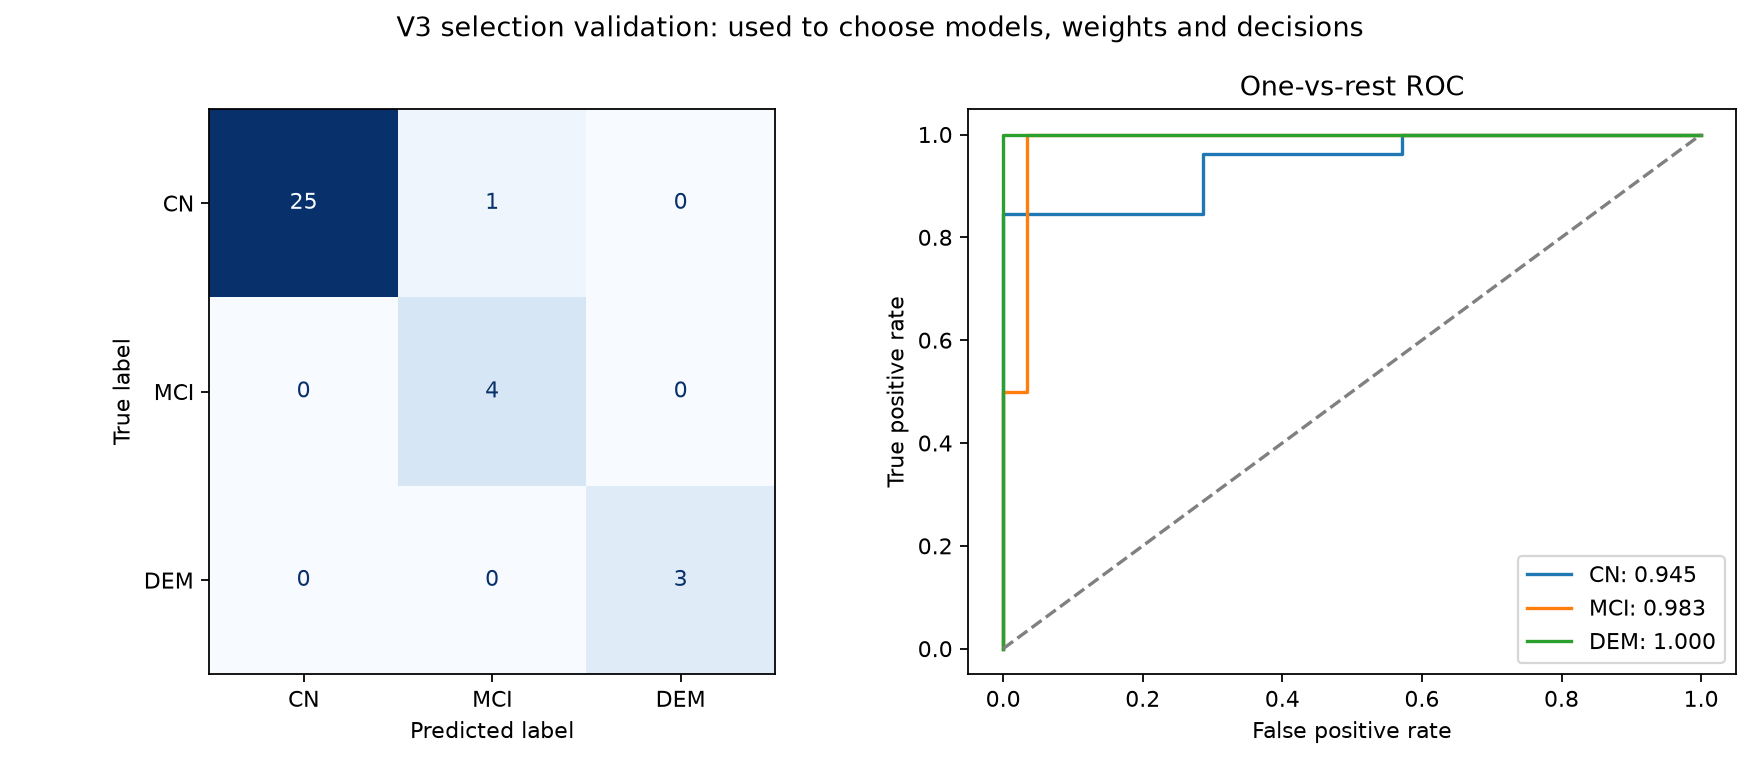

In [8]:
summary_path = OUTPUT / 'summary.json'
if summary_path.exists():
    summary = json.loads(summary_path.read_text())
    display(Markdown('**평가 범위: 선택용 Validation — 모델·가중치·결정 offset 선택에 사용**'))
    display(pd.Series(summary['selection_metrics'], name='V3'))
    display(pd.Series(summary['target_status'], name='목표 달성 여부'))
    print('사용한 수집 시점 특징:', summary['collection_context_features_used'])
    print('최고 모델:', summary['saved_model'])
    display(Image(filename=str(OUTPUT / 'selection_evaluation.png')))
else:
    print('V3 실제 학습 결과가 아직 없습니다. 위 학습 셀을 실행해야 성능을 판단할 수 있습니다.')


In [9]:
for filename in ['controlled_ablations.csv', 'best_by_search_stage.csv', 'classification_report.csv']:
    path = OUTPUT / filename
    if path.exists():
        display(Markdown('**' + filename + '**'))
        display(pd.read_csv(path))
if (OUTPUT / 'candidate_selection_scores.csv').exists():
    display(pd.read_csv(OUTPUT / 'candidate_selection_scores.csv').sort_values('objective', ascending=False).head(20))


**controlled_ablations.csv**

,ablation,candidate_id,status,roc_auc_macro_ovr,macro_recall,macro_f1,accuracy,log_loss,recall_CN,auc_CN_ovr,n_CN,recall_MCI,auc_MCI_ovr,n_MCI,recall_DEM,auc_DEM_ovr,n_DEM,delta_roc_auc_macro_ovr,delta_macro_recall
0,reference,02b04268655bcb88563766e3,ok,0.680091,0.717949,0.347222,0.333333,0.803402,0.153846,0.582418,26,1.00,0.568966,4,1.000000,0.888889,3,0.000000,0.000000
1,add_collection_context,bf9d6a71eeb2c50e1afe6609,ok,0.680091,0.717949,0.347222,0.333333,0.803402,0.153846,0.582418,26,1.00,0.568966,4,1.000000,0.888889,3,0.000000,0.000000
2,context_only,4c96c6fa75ac0400a4dade7d,ok,0.745679,0.658120,0.600529,0.757576,0.823646,0.807692,0.752747,26,0.50,0.862069,4,0.666667,0.622222,3,0.065589,-0.059829
3,activity_only,374d8386b083439217854d34,ok,0.885418,0.897436,0.736219,0.757576,0.594764,0.692308,0.868132,26,1.00,0.810345,4,1.000000,0.977778,3,0.205327,0.179487
4,sleep_only,fd9416d00a997b1affea48bb,ok,0.647498,0.705128,0.325828,0.303030,0.822999,0.115385,0.554945,26,1.00,0.543103,4,1.000000,0.844444,3,-0.032593,-0.012821
5,legacy_only,35ae15ff1a54de5306e0a074,ok,0.567575,0.666667,0.308244,0.212121,0.854129,0.000000,0.461538,26,1.00,0.318966,4,1.000000,0.922222,3,-0.112515,-0.051282
6,temporal_only,a640ff620251c1def28e93c0,ok,0.561454,0.564103,0.392857,0.636364,0.766020,0.692308,0.510989,26,0.00,0.284483,4,1.000000,0.888889,3,-0.118637,-0.153846
7,no_class_balance,1c74c743bad83e982f820030,ok,0.658014,0.658120,0.481649,0.424242,0.737664,0.307692,0.560440,26,1.00,0.491379,4,0.666667,0.922222,3,-0.022077,-0.059829
8,sqrt_class_balance,552d20fa2f9699a0606c5752,ok,0.640984,0.705128,0.322377,0.303030,0.753430,0.115385,0.554945,26,1.00,0.456897,4,1.000000,0.911111,3,-0.039106,-0.012821
9,smote,d85e8f9678b8c5fbbd96dfb0,ok,0.660269,0.673077,0.396364,0.393939,0.799240,0.269231,0.554945,26,0.75,0.525862,4,1.000000,0.900000,3,-0.019822,-0.044872


**best_by_search_stage.csv**

,stage,recipe_id,objective,roc_auc_macro_ovr,macro_recall,macro_f1,accuracy,log_loss,recall_CN,auc_CN_ovr,n_CN,recall_MCI,auc_MCI_ovr,n_MCI,recall_DEM,auc_DEM_ovr,n_DEM
0,offset_refinement,6b2d0433f6a3697836a7065cfe6ed84499432b270f426d...,1.996525,0.975938,0.987179,0.956427,0.969697,1.094045,0.961538,0.945055,26,1.0,0.982759,4,1.0,1.000000,3
1,soft_vote,6b2d0433f6a3697836a7065cfe6ed84499432b270f426d...,1.996525,0.975938,0.987179,0.956427,0.969697,1.094045,0.961538,0.945055,26,1.0,0.982759,4,1.0,1.000000,3
2,score_transform,bea4464bef69772ea6ea02de17c795e906f5c0f44cc064...,1.981708,0.966528,0.961538,0.888683,0.909091,0.842038,0.884615,0.934066,26,1.0,0.965517,4,1.0,1.000000,3
3,hierarchy,bd751b57adf9acbf084119acc2c4343dfc501d06925b0e...,1.959524,0.939624,0.961538,0.888683,0.909091,0.522362,0.884615,0.939560,26,1.0,0.879310,4,1.0,1.000000,3
4,direct_3class,1ce126d446e4e2e64d905c484eb6e90482ee10c12b4abe...,1.903983,0.885418,0.897436,0.736219,0.757576,0.594764,0.692308,0.868132,26,1.0,0.810345,4,1.0,0.977778,3


**classification_report.csv**

,Unnamed: 0,precision,recall,f1-score,support
0,CN,1.000000,0.961538,0.980392,26.000000
1,MCI,0.800000,1.000000,0.888889,4.000000
2,DEM,1.000000,1.000000,1.000000,3.000000
3,accuracy,0.969697,0.969697,0.969697,0.969697
4,macro avg,0.933333,0.987179,0.956427,33.000000
5,weighted avg,0.975758,0.969697,0.971083,33.000000


,id,task,family,view,representation,top_k,selection,augmentation,objective,seconds,...,auc_CN_ovr,n_CN,recall_MCI,auc_MCI_ovr,n_MCI,recall_DEM,auc_DEM_ovr,n_DEM,binary_auc,binary_best_balanced_recall_selection
43,374d8386b083439217854d34,flat,catboost,activity,subject,40,anova,none,1.903983,0.294273,...,0.868132,26.0,1.00,0.810345,4.0,1.000000,0.977778,3.0,NaN,NaN
111,33fa8d46234844f7c523b226,flat,lda,compact,subject,all,anova,none,1.842861,0.018091,...,0.917582,26.0,1.00,0.870690,4.0,0.666667,0.933333,3.0,NaN,NaN
77,c25fb8dca443b46c95905c1b,flat,logreg,compact,subject,all,anova,jitter,1.831398,0.021366,...,0.917582,26.0,0.75,0.689655,4.0,1.000000,0.944444,3.0,NaN,NaN
291,d4ac34b15263a28739c5c157,dem,rbf_ridge,all,subject,80,rfe,none,1.020000,0.445290,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000
226,617161bd23138da985fb4f61,dem,logreg,no_context,subject,160,mutual_info,smote,1.020000,2.979327,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000
223,df250a96b4f6cdfdc8f6871a,dem,catboost,activity_variability,subject,40,anova,none,1.020000,1.633568,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000
253,ba31ac4c7efee5778db8c0c4,dem,lda,dem_single,subject,all,anova,jitter,1.008556,0.008326,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.988889,0.983333
254,f4724280fa54667c84078100,dem,lda,dem_single,subject,all,anova,jitter,1.008556,0.008509,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.988889,0.983333
294,be0a10df641d92bfee639d33,dem,rbf_ridge,activity,subject,20,rfe,smote,1.008556,0.157738,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.988889,0.983333
295,d02843f9ccbf76116ea9a456,dem,rbf_ridge,activity,subject,80,rfe,none,1.008556,0.156117,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.988889,0.983333


## 저장된 모델로 새 파일 예측

아래 셀은 함수를 정의합니다. 실제 활동·수면 CSV 경로로 호출하면 진단 정답 파일 없이 피험자별 score와 분류를 반환합니다. 학습에 쓴 것과 같은 원본 CSV 열 형식이 필요합니다.


In [10]:
def predict_new_subjects(activity_csv, sleep_csv):
    import joblib
    model_path = OUTPUT / 'champion_selection_only.joblib'
    if not model_path.exists():
        raise FileNotFoundError('V3 학습을 먼저 완료하세요.')
    champion = joblib.load(model_path)
    return champion.predict_csv(activity_csv, sleep_csv)

# predictions = predict_new_subjects('/path/to/activity.csv', '/path/to/sleep.csv')
# predictions.to_csv('new_subject_predictions.csv')


## 구현·검증 기록

- `lifelog_v3/data.py`: 라벨에 의존하지 않는 개인별 특징 추출.
- `models.py`: Training 내부 전처리·특징 선택·증강·10개 모델 계열.
- `search.py`, `selection.py`: 통제 ablation·계열별 Optuna·계층 결합·score 및 결정 정책 탐색.
- `report.py`: 결과·혼동행렬·ROC·후보별 표·모델 저장 안내.
- `results_v3/`: 실제 학습 전 준비·계약·인공 데이터 native 라이브러리 검증 기록.

기존 V1/V2와 원본 데이터는 보존합니다. V3의 목표 달성은 실제 실행 결과로 확인해야 합니다.
